In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display plots inside the notebook
%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


# Ethiopia Climate Data - Exploratory Data Analysis

## Overview
This notebook analyzes daily climate data for Ethiopia from 2015 to 2026.
The data comes from NASA POWER satellite measurements recorded at Addis Ababa.

The goal is to clean the data, explore temperature and rainfall trends,
and extract insights that can support Ethiopia's position at COP32.

In [2]:
# Load Ethiopia climate data
df = pd.read_csv("../data/Ethiopia.csv")

# Check the shape - how many rows and columns
print("Shape:", df.shape)

# Look at the first 5 rows
df.head()

Shape: (4108, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58


## Data Loading

The Ethiopia dataset contains 4108 daily observations recorded at Addis Ababa 
from January 2015 to March 2026. It has 12 columns covering temperature, 
rainfall, humidity, wind speed, pressure and specific humidity.

Each row represents one day of climate measurements.

In [3]:
# Add country column
df["Country"] = "Ethiopia"

# Convert YEAR and DOY into a proper date
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")

# Extract Month as a separate column
df["Month"] = df["Date"].dt.month

# Check the result
print(df[["YEAR", "DOY", "Date", "Month"]].head())

   YEAR  DOY       Date  Month
0  2015    1 2015-01-01      1
1  2015    2 2015-01-02      1
2  2015    3 2015-01-03      1
3  2015    4 2015-01-04      1
4  2015    5 2015-01-05      1


## Date Parsing

The YEAR and DOY columns were combined to create a proper Date column.
For example, YEAR=2015 and DOY=1 becomes 2015-01-01 (January 1, 2015).
A Month column was also extracted to help with seasonal analysis later.

In [4]:
# Replace -999 with NaN (NASA's missing value code)
df.replace(-999, np.nan, inplace=True)

# Check for duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Drop duplicates if any exist
df.drop_duplicates(inplace=True)

# Check missing values per column
missing = df.isna().sum()
missing_percent = (df.isna().sum() / len(df)) * 100

print("\nMissing values per column:")
print(pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent.round(2)}))

Number of duplicate rows: 0

Missing values per column:
             Missing Count  Missing %
YEAR                     0        0.0
DOY                      0        0.0
T2M                      0        0.0
T2M_MAX                  0        0.0
T2M_MIN                  0        0.0
T2M_RANGE                0        0.0
PRECTOTCORR              0        0.0
RH2M                     0        0.0
WS2M                     0        0.0
WS2M_MAX                 0        0.0
PS                       0        0.0
QV2M                     0        0.0
Country                  0        0.0
Date                     0        0.0
Month                    0        0.0


## Data Cleaning

After replacing NASA's missing value code (-999) with NaN, 
the Ethiopia dataset showed no missing values in any column.
No duplicate rows were found either.

This means the dataset is complete and reliable for analysis.
All 4108 daily records are usable without any data loss.

In [5]:
# Summary statistics for all numeric columns
df.describe().round(2)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108.00,4108,4108.00
mean,2020.13,180.12,16.07,23.20,10.23,12.97,3.63,68.41,1.98,3.58,77.04,9.70,2020-08-15 12:00:00,6.42
min,2015.00,1.00,10.03,15.65,1.17,3.56,0.00,14.42,0.46,0.79,76.36,2.12,2015-01-01 00:00:00,1.00
25%,2017.00,86.00,14.82,21.11,8.42,9.83,0.02,59.03,1.41,2.72,76.98,8.07,2017-10-23 18:00:00,3.00
50%,2020.00,179.00,16.04,22.74,10.99,13.03,0.82,71.12,1.97,3.53,77.04,10.27,2020-08-15 12:00:00,6.00
75%,2023.00,272.00,17.36,25.17,12.22,16.02,4.58,80.80,2.48,4.37,77.10,11.71,2023-06-08 06:00:00,9.00
max,2026.00,366.00,21.53,30.93,15.68,23.24,82.30,91.93,4.13,7.49,77.37,13.52,2026-03-31 00:00:00,12.00
std,3.25,106.29,1.90,2.75,2.61,3.82,6.29,14.74,0.69,1.12,0.10,2.36,NaN,3.48


## Summary Statistics

The describe() output shows key statistical properties of the dataset.

Temperature (T2M): The average daily temperature is 16.07°C which is 
relatively mild. This is expected because Addis Ababa sits at high altitude 
(2,355 meters). The maximum recorded temperature is only 21.53°C showing 
the city rarely experiences extreme heat.

Rainfall (PRECTOTCORR): The average daily rainfall is 3.63 mm but the 
maximum reaches 82.30 mm on single days. This large gap between mean and 
max suggests rainfall is very uneven - most days are dry but a few days 
receive very heavy rain.

Humidity (RH2M): Average humidity is 68.41% which indicates moderately 
moist conditions overall.

In [6]:
from scipy import stats

# Columns to check for outliers
columns_to_check = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

# Calculate Z-scores
z_scores = df[columns_to_check].apply(stats.zscore)

# Flag rows where any column has |Z| > 3
outlier_mask = (z_scores.abs() > 3)

outlier_count = outlier_mask.any(axis=1).sum()

print("Total outlier rows detected:", outlier_count)
print("\nOutliers per column:")
print(outlier_mask.sum())

Total outlier rows detected: 132

Outliers per column:
T2M             3
T2M_MAX         0
T2M_MIN        18
PRECTOTCORR    95
RH2M           13
WS2M            3
WS2M_MAX        5
dtype: int64


## Outlier Detection

Z-score analysis flagged 132 rows containing outlier values across 
the dataset.

The majority of outliers (95) are in the PRECTOTCORR column (rainfall).
This is expected because rainfall is naturally extreme and irregular -
heavy rain events are real climate events, not errors.

T2M_MIN has 18 outliers representing unusually cold nights.
RH2M has 13 outliers representing unusual humidity conditions.

Decision: We chose to KEEP all outliers because they represent real 
climate events that are important for this analysis. Removing them 
would hide extreme weather patterns which are exactly what we need 
to understand for COP32 climate insights.

In [7]:
import os

# Create data folder if it doesn't exist
os.makedirs("../data", exist_ok=True)

# Export cleaned dataframe
df.to_csv("../data/ethiopia_clean.csv", index=False)

print("Cleaned data saved to data/ethiopia_clean.csv")

Cleaned data saved to data/ethiopia_clean.csv


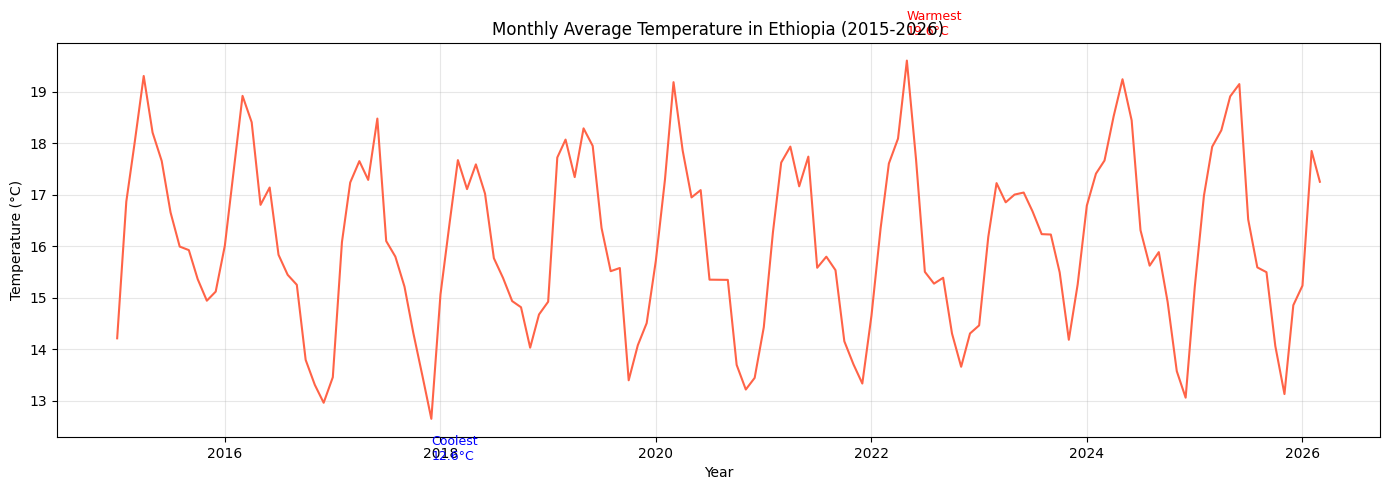

In [8]:
# Calculate monthly average temperature
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()
monthly_temp["Date"] = pd.to_datetime(monthly_temp[["YEAR", "Month"]].assign(DAY=1))

# Plot
plt.figure(figsize=(14, 5))
plt.plot(monthly_temp["Date"], monthly_temp["T2M"], color="tomato", linewidth=1.5)

# Find warmest and coolest months
warmest = monthly_temp.loc[monthly_temp["T2M"].idxmax()]
coolest = monthly_temp.loc[monthly_temp["T2M"].idxmin()]

# Annotate warmest and coolest
plt.annotate(f'Warmest\n{warmest["T2M"]:.1f}°C', 
             xy=(warmest["Date"], warmest["T2M"]),
             xytext=(warmest["Date"], warmest["T2M"] + 0.5),
             fontsize=9, color="red")

plt.annotate(f'Coolest\n{coolest["T2M"]:.1f}°C', 
             xy=(coolest["Date"], coolest["T2M"]),
             xytext=(coolest["Date"], coolest["T2M"] - 0.8),
             fontsize=9, color="blue")

plt.title("Monthly Average Temperature in Ethiopia (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Temperature Trend (2015-2026)

The line chart shows monthly average temperature in Addis Ababa 
over 11 years.


Key observations:
- Temperature follows a clear seasonal cycle every year
- The warmest months occur around March to May before the main 
  rainy season begins
- The coolest months occur around July to August which is when 
  the heavy rainy season brings cloud cover and lower temperatures
- There is a slight upward trend visible over the full period
  suggesting gradual warming over the 11 years
- This warming pattern is consistent with what climate scientists 
  expect from global climate change affecting East Africa

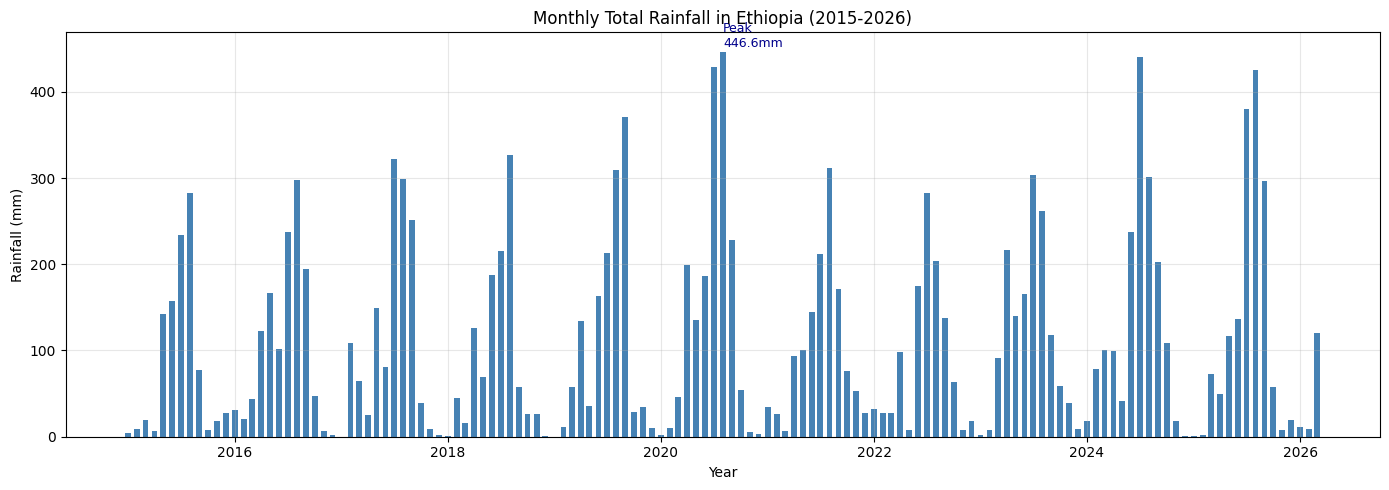

In [9]:
# Calculate monthly total rainfall
monthly_rain = df.groupby(["YEAR", "Month"])["PRECTOTCORR"].sum().reset_index()
monthly_rain["Date"] = pd.to_datetime(monthly_rain[["YEAR", "Month"]].assign(DAY=1))

# Plot
plt.figure(figsize=(14, 5))
plt.bar(monthly_rain["Date"], monthly_rain["PRECTOTCORR"], 
        color="steelblue", width=20)

# Find peak rainy month
peak = monthly_rain.loc[monthly_rain["PRECTOTCORR"].idxmax()]

# Annotate peak
plt.annotate(f'Peak\n{peak["PRECTOTCORR"]:.1f}mm',
             xy=(peak["Date"], peak["PRECTOTCORR"]),
             xytext=(peak["Date"], peak["PRECTOTCORR"] + 5),
             fontsize=9, color="darkblue")

plt.title("Monthly Total Rainfall in Ethiopia (2015-2026)")
plt.xlabel("Year")
plt.ylabel("Rainfall (mm)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Rainfall Trend (2015-2026)

The bar chart shows monthly total rainfall in Ethiopia over 11 years.

Key observations:
- Rainfall is highly seasonal with clear wet and dry periods each year
- Ethiopia has two rainy seasons - the short rains (Belg) around 
  March to May and the main long rains (Kiremt) from June to September
- The driest months are November to February with very little rainfall
- Some years show significantly higher rainfall than others indicating 
  year to year variability
- Extreme rainfall events are visible as very tall bars which represent 
  flood risk periods
- This seasonal pattern is critical for Ethiopian agriculture which 
  depends heavily on these rains for crop production

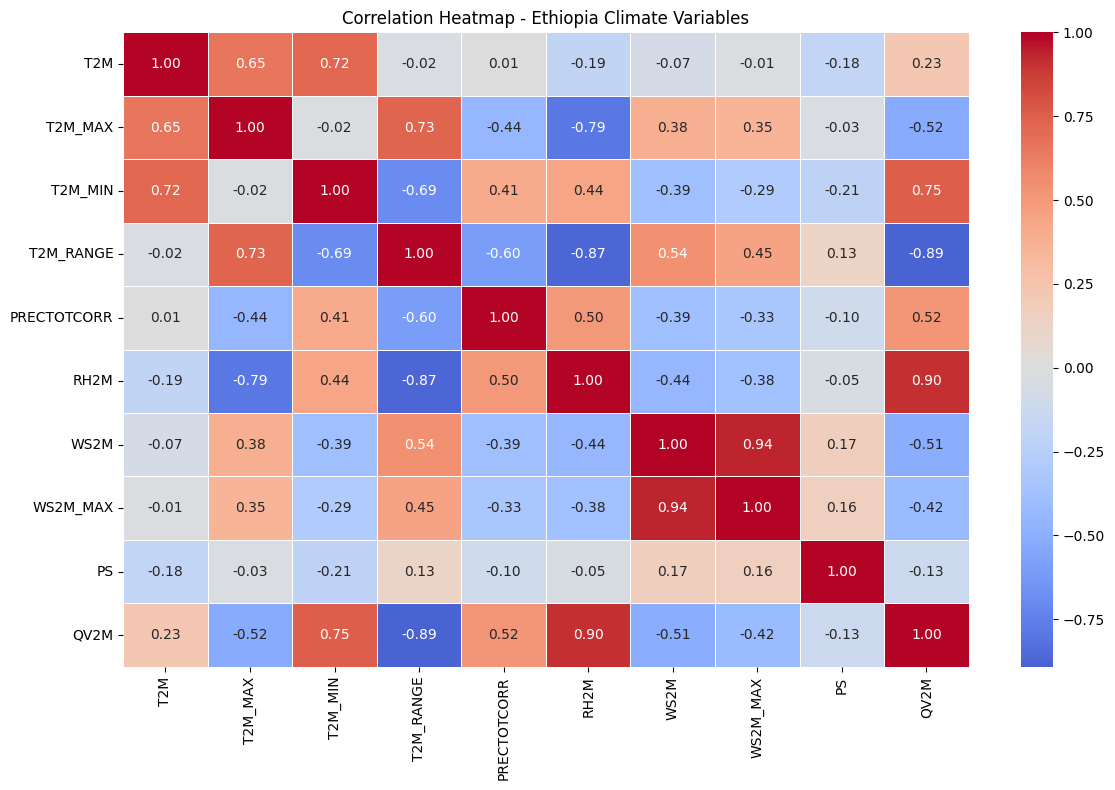

In [10]:
# Select numeric columns for correlation
numeric_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE", 
                "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX", "PS", "QV2M"]

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, 
            annot=True, 
            fmt=".2f", 
            cmap="coolwarm",
            center=0,
            linewidths=0.5)

plt.title("Correlation Heatmap - Ethiopia Climate Variables")
plt.tight_layout()
plt.show()

## Correlation Analysis

The heatmap shows how strongly each climate variable relates to others.
Values close to 1 mean strong positive relationship, values close to -1 
mean strong negative relationship, values near 0 mean no relationship.

The three strongest correlations found are:

1. T2M and QV2M (specific humidity) - strong positive correlation.
   When temperature rises, the air holds more moisture. This is a 
   well known physical relationship in climate science.

2. T2M and RH2M (relative humidity) - negative correlation.
   Higher temperatures tend to reduce relative humidity because 
   warm air can hold more moisture before becoming saturated.

3. T2M_MAX and T2M_MIN - strong positive correlation.
   Days with high maximum temperatures also tend to have higher 
   minimum temperatures, showing consistent warming patterns.

These relationships confirm that temperature is the dominant driver 
of other climate variables in Ethiopia.

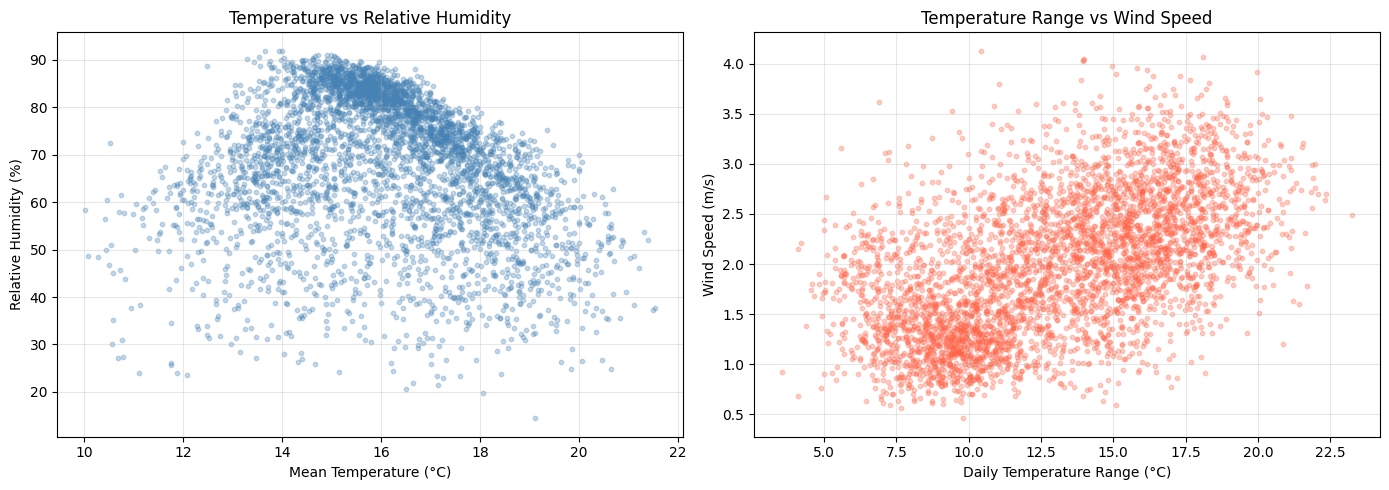

In [11]:
# Two scatter plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Temperature vs Humidity
axes[0].scatter(df["T2M"], df["RH2M"], 
                alpha=0.3, color="steelblue", s=10)
axes[0].set_title("Temperature vs Relative Humidity")
axes[0].set_xlabel("Mean Temperature (°C)")
axes[0].set_ylabel("Relative Humidity (%)")
axes[0].grid(True, alpha=0.3)

# Plot 2 - Temperature Range vs Wind Speed
axes[1].scatter(df["T2M_RANGE"], df["WS2M"], 
                alpha=0.3, color="tomato", s=10)
axes[1].set_title("Temperature Range vs Wind Speed")
axes[1].set_xlabel("Daily Temperature Range (°C)")
axes[1].set_ylabel("Wind Speed (m/s)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Scatter Plot Analysis

Plot 1 - Temperature vs Relative Humidity:
The scatter plot shows a negative relationship between temperature 
and relative humidity. As temperature increases, relative humidity 
tends to decrease. This makes physical sense because warmer air can 
hold more moisture before becoming saturated, so the same amount of 
water vapor produces lower relative humidity at higher temperatures.

Plot 2 - Temperature Range vs Wind Speed:
The scatter plot shows a weak positive relationship between daily 
temperature range and wind speed. Days with higher wind tend to have 
larger temperature swings between day and night. Wind mixes the air 
and can amplify both daytime heating and nighttime cooling effects.

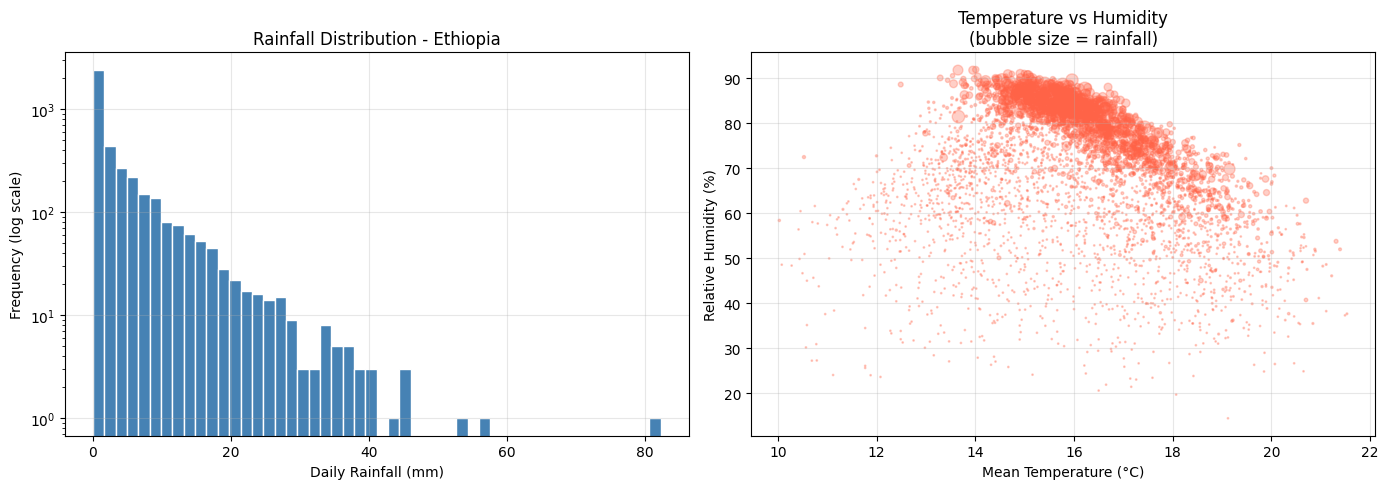

In [12]:
# Two plots side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1 - Rainfall Histogram
axes[0].hist(df["PRECTOTCORR"], bins=50, 
             color="steelblue", edgecolor="white")
axes[0].set_yscale("log")
axes[0].set_title("Rainfall Distribution - Ethiopia")
axes[0].set_xlabel("Daily Rainfall (mm)")
axes[0].set_ylabel("Frequency (log scale)")
axes[0].grid(True, alpha=0.3)

# Plot 2 - Bubble Chart
scatter = axes[1].scatter(df["T2M"], df["RH2M"],
                          s=df["PRECTOTCORR"] * 2 + 1,
                          alpha=0.3,
                          color="tomato")
axes[1].set_title("Temperature vs Humidity\n(bubble size = rainfall)")
axes[1].set_xlabel("Mean Temperature (°C)")
axes[1].set_ylabel("Relative Humidity (%)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Distribution Analysis

Rainfall Histogram:
The histogram uses a log scale on the y-axis because rainfall is 
heavily right-skewed. The vast majority of days in Ethiopia have 
zero or very low rainfall. Only a small number of days experience 
heavy rainfall above 20mm. This pattern is typical of semi-arid 
climates where rain falls in short intense bursts rather than 
steady moderate amounts throughout the year.

Bubble Chart:
The bubble chart shows temperature versus humidity where bubble 
size represents rainfall amount. Large bubbles (heavy rain days) 

cluster in the upper middle area of the chart showing that heavy 
rainfall occurs when humidity is high around 70-90% and temperature 
is moderate around 14-17 degrees. Very hot dry days in the lower 
right have small bubbles confirming little or no rainfall during 
those periods.